## Imports

In [1]:
import numpy as np
from tqdm import tqdm
from copy import deepcopy
import matplotlib.pyplot as plt
%matplotlib inline

import dm_control
from dm_control.mujoco.wrapper.core import MjvOption
import mujoco as mj
from scipy.io import savemat
from lxml import etree
import mediapy as media

from flybody.fly_envs import (
    flight_imitation,
    vision_guided_flight,
)
from flybody.tasks.task_utils import (
    get_random_policy,
    real2canonical,
)
from flybody.tasks.constants import _FLY_PHYSICS_TIMESTEP, _FLY_CONTROL_TIMESTEP, _BODY_PITCH_ANGLE
from flybody.tasks.synthetic_trajectories import constant_speed_trajectory
from flybody.agents.utils_tf import TestPolicyWrapper
from flybody.utils import (
    display_video,
    rollout_and_render,
    rollout_ablate_render,
)
from flybody.quaternions import rotate_vec_with_quat, reciprocal_quat
import flybody.fruitfly.assets

import tensorflow as tf
import tensorflow_probability as tfp
from acme import wrappers

# Prevent tensorflow from stealing all gpu memory.
physical_devices = tf.config.list_physical_devices('GPU')
print("physical devices:",physical_devices)
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

2026-01-12 14:42:00.147936: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-01-12 14:42:00.147958: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
/home/exj5139/miniconda3/envs/flybody/lib/python3.10/site-packages/tensorflow/python/framework/dtypes.py:205: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  np.bool8: (False, True),
/home/exj5139/miniconda3/envs/flybody/lib/python3.10/site-packages/tensorboard/compat/tensorflow_stub/dtypes.py:326: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  np.bool8: (False, True),
/home/exj5139/miniconda3/envs/flybody/lib/python3.10/site-packages/reverb/platform/default/ensure_tf_install.py:53: DeprecationWarning: distuti

physical devices: []


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-01-12 14:42:01.982734: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-01-12 14:42:01.982786: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-01-12 14:42:01.982810: W tensorflow/str

### Initialization

In [2]:
# follow this chart for editing fruitfly.xml
#war,l1,y,mass
#0.5,0.057,0.091,4e-06
#0.6,0.0684,0.1024,4.8e-06
#0.7,0.0798,0.1138,5.6e-06
#0.8,0.0912,0.1252,6.4e-06
#0.9,0.1026,0.1366,7.2e-06
#1.0,0.1140,0.1480,8e-06

flight_imitation_path = '/home/exj5139/Downloads/datasets_flight-imitation/'
wpg_pattern_path    = flight_imitation_path+'wing_pattern_fmech.npy'
ref_flight_path     = flight_imitation_path+'flight-dataset_saccade-evasion_augmented.hdf5'

policy_path = '/home/exj5139/Downloads/trained-fly-policies/'
flight_policy_path  = policy_path+'flight'
vision_bumps_path   = policy_path+'vision-bumps'
vision_trench_path  = policy_path+'vision-trench'

ff_venv_path = ''
ff_source_path = flybody.__path__[0]+'/fruitfly/build_fruitfly/fruitfly.xml'
ff_working_path= flybody.__path__[0]+'/fruitfly/assets/fruitfly.xml'
# User define here
t_total     = 0.08 # total simulation time, s: this is a rough approximation of the maximum time it would take for a fly to free-fall past the trajectory error limit
fly_speed   = 20. # cm/s default 20
# war_range   = range(0.5,1.01,0.01) # range of war values to simulate
war_step = 0.01
n_episodes = 1 # number of episodes to attempt for the given war
record_episode = False
saveResults = True

### Definitions

In [3]:
# Rendering options
scene_opt = MjvOption()
scene_opt.geomgroup = [1,0,0,1,1,0]
render_kwargs = {'width': 640, 'height': 480, 'scene_option': scene_opt}

# Allocate.
n_steps = int(t_total /_FLY_PHYSICS_TIMESTEP) # frames
wars = np.arange(0.5,1+0.5*war_step,war_step)
# frames_between_render = max(1, int(t_total / (_FLY_PHYSICS_TIMESTEP * t_video * framerate))) # number of frames to wait before rendering next frame, based on the input parameters
# frames_0 = []
# frames_1 = []
# joints_pos  = np.nan * np.zeros((n_steps, 25))  # Proprioception: observable joint angles.
# vel         = np.nan * np.zeros((n_steps, 3))  # Velocimeter.
# zaxis       = np.nan * np.zeros((n_steps, 3))  # Gravity direction.
# root_qpos   = np.nan * np.zeros((n_steps, 7))  # Fly's position and orientation.
# actions     = np.nan * np.zeros((n_steps, 6))  # Wing action commands.

# Simulation state save
flybody_state = {
    "root_pos": np.nan * np.zeros((n_steps, 7)),
    "joint_pos": {
        "head": np.nan * np.zeros((n_steps, 3)),
        "wing": np.nan * np.zeros((n_steps, 6)),
        "abdomen": np.nan * np.zeros((n_steps, 14)),
        "halteres": np.nan * np.zeros((n_steps,2))
    },
    "action": {
        "head": np.nan * np.zeros((n_steps, 3)),
        "wing": np.nan * np.zeros((n_steps, 6)),
        "abdomen": np.nan * np.zeros((n_steps, 2)),
        "freqMod": np.nan *np.zeros((n_steps,1))
    },
    "force": np.nan * np.zeros((n_steps, 3)),
    "torque": np.nan * np.zeros((n_steps, 3)),
    "acceleration": np.nan * np.zeros((n_steps, 3)),
    "abdomen_vecang": np.nan *np.zeros((n_steps,4)),
    "war": np.nan,
    "timestep": np.nan
}

print("total steps:",n_steps)

ROOT_QPOS0 = np.array([0,0,1,np.cos(np.deg2rad(_BODY_PITCH_ANGLE)*0.5),0,-np.sin(np.deg2rad(_BODY_PITCH_ANGLE)*0.5),0])

def blow(x, repeats=2):
    """Repeat columns and rows requested number of times."""
    return np.repeat(np.repeat(x, repeats, axis=0), repeats, axis=1)


def vision_rollout_and_render(env, policy, camera_id=1,
                              eye_blow_factor=5, **render_kwargs):
    """Run vision-guided flight episode and render frames, including eyes."""
    frames = []
    timestep = env.reset()
    # Run full episode until it ends.
    while timestep.step_type != 2:
        # Render eyes and scene.
        pixels = env.physics.render(camera_id=camera_id, **render_kwargs)
        eyes = eye_pixels_from_observation(
            timestep, blow_factor=eye_blow_factor)
        # Add eye pixels to scene.
        pixels[0:eyes.shape[0], 0:eyes.shape[1], :] = eyes
        frames.append(pixels)
        # Step environment.
        action = policy(timestep.observation)
        timestep = env.step(action)
    return frames


def eye_pixels_from_observation(timestep, blow_factor=4):
    """Get current eye view from timestep.observation."""
    # In the actual task, the averaging over axis=-1 is done by the visual
    # network as a pre-processing step, so effectively the visual observations
    # are gray-scale.
    left_eye = timestep.observation['walker/left_eye'].mean(axis=-1)
    right_eye = timestep.observation['walker/right_eye'].mean(axis=-1)
    pixels = np.concatenate((left_eye, right_eye), axis=1)
    pixels = np.tile(pixels[:, :, None], reps=(1, 1, 3))
    pixels = blow(pixels, blow_factor)
    half_size = pixels.shape[1] // 2
    # Add white line to separate eyes.
    pixels = np.concatenate((pixels[:, :half_size, :], 
                            255*np.ones((blow_factor*32, 2, 3)),
                            pixels[:, half_size:, :]), axis=1)
    pixels = pixels.astype('uint8')
    return pixels


def eye_pixels_from_cameras(physics, **render_kwargs):
    """Render two-eye view, assuming eye cameras have particular names."""
    for i in range(physics.model.ncam):
        name = physics.model.id2name(i, 'camera')
        if 'eye_left' in name:
            left_eye = physics.render(camera_id=i, **render_kwargs)
        if 'eye_right' in name:
            right_eye = physics.render(camera_id=i, **render_kwargs)
    pixels = np.hstack((left_eye, right_eye))
    return pixels

def plot(save_dir,ctrl_ts, joints_pos, actions, root_qpos):
    time_axis = np.arange(n_steps) * ctrl_ts * 1000  # ms
    joint_labels = []
    for i in range(7):
        joint_labels.append(f"abduct{i}")
        joint_labels.append(f"extend{i}")
    
    # Proprioception plot
    plt.figure(figsize=(6, 10))
    plt.suptitle('Proprioception sensory inputs: head, abdomen, wing joint angles')
    plt.subplot(4, 1, 1)  # Head joints.
    plt.plot(time_axis, joints_pos[:, :3], label=['head_abduct', 'head_twist', 'head'])
    plt.ylabel('Head joint angles (rad)')
    plt.legend()
    plt.subplot(4, 1, 2)  # Abdomen joints.
    plt.plot(time_axis, joints_pos[:, 9:23], label=joint_labels)
    plt.ylabel('Abdomen joint angles (rad)')
    plt.subplot(4, 1, 3)  # Left wing.
    plt.plot(time_axis, joints_pos[:, 3:6], label=['yaw', 'roll', 'pitch'])
    plt.ylabel('Left wing angles (rad)')
    plt.legend()
    plt.subplot(4, 1, 4)  # Right wing.
    plt.plot(time_axis, joints_pos[:, 6:9])
    plt.xlabel('Time (ms)')
    plt.ylabel('Right wing angles (rad)')
    plt.tight_layout()
    plt.savefig(save_dir+r"proprioception.svg")

    # Dimensionless action specs
    plt.figure(figsize=(6,10))
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, actions[:, :3], label=['yaw', 'roll', 'pitch'])
    plt.ylabel('Left wing control\n(unitless)')
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, actions[:, 3:])
    plt.xlabel('Time (ms)')
    plt.ylabel('Right wing control')
    plt.tight_layout()
    plt.savefig(save_dir+r"wing_actions.svg")

    # Position
    plt.figure(figsize=(6,10))
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, root_qpos[:, :3], label=['x', 'y', 'z'])
    plt.ylabel('Global Position (cm)')
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(time_axis, root_qpos[:, 3:], label=['w', 'x', 'y', 'z'])
    plt.xlabel('Time (ms)')
    plt.ylabel('Global Quaternion')
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_dir+r"pose.svg")

def damageModel(war: float):
    # Begin editing the model
    fname = '/home/exj5139/Documents/repos/flybody/flybody/fruitfly/assets/'
    spec = mj.MjSpec.from_file(fname+'fruitfly_old.xml')

    # Clip wing
    len_0 = spec.geom("wing_right_fluid").size[2]
    len_1 = len_0 * war
    for ftype in ["fluid", "inertial"]:
        geom = spec.geom("wing_right_"+ftype)
        geom.size[2] = len_1
        geom.pos[1] += len_1-len_0
        geom.mass *= war

    # Add force/torque sensors
    spec.add_sensor(
        name='thorax_force',
        type=mj.mjtSensor.mjSENS_FORCE,
        objtype=mj.mjtObj.mjOBJ_SITE,
        objname='thorax')
    spec.add_sensor(
        name='thorax_torque',
        type=mj.mjtSensor.mjSENS_TORQUE,
        objtype=mj.mjtObj.mjOBJ_SITE,
        objname='thorax')
    
    # save the model to where Flybody is expecting it to be
    spec.compile()
    spec.to_file(fname+'fruitfly.xml')

def CalculateNetForce(
        data: dm_control.mujoco.MjData,
        nbody_index = 1,
        reference_force: float = 1.,
        reference_torque: float = 1.):
    """Calculates the net force/torque experienced by a body at its COM
    Args:
        data: the MjData object
        nbody_index: the nth body to analyze within the model, defaults to the 
            first body after the worldbody
        reference_force: some force value to optionally normalize by
        reference_torque: some torque value to optionally normalize by
    Returns:
        (normalized) force
        (normalized) torque"""
    # Simulation variables
    inertia = data.cinert[nbody_index][0:9].reshape((3,3))
    mass = data.cinert[nbody_index][9]
    angvel = data.cvel[nbody_index][0:3]
    # linvel = data.cvel[nbody_index][3:6] # not needed
    angacc = data.cacc[nbody_index][0:3]
    linacc = data.cacc[nbody_index][3:6]
    
    # Newton-Euler Equations of Motion
    force = mass*linacc
    torque = np.matmul(inertia,angacc) + np.cross(angvel,np.matmul(inertia,angvel))
    
    return force/reference_force, torque/reference_torque

def CutRightWing(ff_source_path: str, ff_working_path: str, war: float):
    """
    Apply a unilateral chordwise cut to the right wing of a fruitfly.xml file.
    
    :param ff_source_path: The local path of the fruitfly.xml file to READ from, ideally a copy of the original file.
    :type ff_source_path: str
    :param ff_working_path: The local path of the fruitfly.xml to WRITE to. Expected to be the location from which an Environment is generated from 
    :type ff_working_path: str
    :param war: Wing Area Ratio. The amount of wing that is left after being damaged. Ranges from (0,1]
    :type war: float
    """
    #with open(ff_source_path,'r') as f: tree = etree.XML(f.read(), etree.XMLParser(remove_blank_text=True))
    tree = etree.parse(ff_source_path)
    
    fluid   = tree.xpath("//geom[@name=\"wing_right_fluid\"]")[0]
    inertial= tree.xpath("//geom[@name=\"wing_right_inertial\"]")[0]

    # Edit wing length
    size0 = fluid.attrib["size"].split(" ") # get initial length as a list of floatlike strings
    size0 = np.array([float(size_i) for size_i in size0]) # make it an array of floats
    len0 = size0[2] # save this value, used later
    size1 = np.array([1,1,war])*size0 # calculate new size
    len1 =  size1[2] # save this too
    size1 = ' '.join(str(size_i) for size_i in size1) # convert back into a space-delimited listlike string

    # Edit wing position
    pos0 = fluid.attrib["pos"].split(" ") # get initial position as a list of floatlike strings
    pos0 = np.array([float(pos_i) for pos_i in pos0]) # convert to array of floats
    pos1 = pos0 + np.array([0,len1-len0,0]) # calculate new position
    pos1 = ' '.join(str(pos_i) for pos_i in pos1) # convert into space-delimited listlike string

    # Add edits to tree
    for geom in [fluid, inertial]:
        geom.attrib["size"] = size1
        geom.attrib["pos"] = pos1
    inertial.attrib["mass"] = str(8e-6 * war) # also set the new mass of inertia

    # Add force/torque sensors
    f_sensor = etree.SubElement(tree.find("sensor"), "force")
    f_sensor.set("name","force_thorax"); f_sensor.set("site","thorax")
    t_sensor = etree.SubElement(tree.find("sensor"), "torque")
    t_sensor.set("name","torque_thorax"); t_sensor.set("site","thorax")


    # print preview
    # print(etree.tostring(fluid))
    # print(etree.tostring(inertial))
    # print(etree.tostring(tree.find("sensor")))

    # Finally, save all edits
    tree.write(ff_working_path)

total steps: 1600


In [4]:
# # test env
# np.set_printoptions(threshold=np.inf)
# env_test = flight_imitation(None,
#                     wpg_pattern_path,
#                     terminal_com_dist=float('inf'))
# ts_test = env_test.reset()
# print(ts_test.observation.keys())
print(wars)

[0.5  0.51 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63
 0.64 0.65 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77
 0.78 0.79 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91
 0.92 0.93 0.94 0.95 0.96 0.97 0.98 0.99 1.  ]


### Simulation

In [ ]:
results = {"cloop":{}, "oloop":{}}
videos = [[],[],[]]
camera = 0

for i,war in enumerate(wars):
    # ADD TRIAL FOR THIS ITERATION #################################################################################
    # Set up this section of the dictionary
    i_str = str(i) # string numbering
    if i < 100: i_str = f"0{i_str}" # prepend one zero if double digits
    if i < 10: i_str = f"0{i_str}"  # prepend two zeroes if single digits
    tName = f"Trial_{i_str}"
    for loop in ["cloop", "oloop"]:
        # fill both closed loop and open loop results with the trial information
        # results[loop][tName] = {}
        results[loop][tName] = deepcopy(flybody_state)
        results[loop][tName]["war"] = war
        results[loop][tName]["timestep"] = _FLY_CONTROL_TIMESTEP
    ###############################################################################################################

    # EDIT MODEL ACCORDING TO WING AREA RATIO #####################################################################
    CutRightWing(ff_source_path,ff_working_path,war)
    ##############################################################################################################

    # SIMULATION INITIALIZATION ######################################################################################
    env = flight_imitation(None,
                        wpg_pattern_path,
                        terminal_com_dist=float('inf'))
    qpos, qvel = constant_speed_trajectory(
                n_steps=n_steps, speed=fly_speed, init_pos=(0, 0, 1),
                body_rot_angle_y=-47.5, control_timestep=_FLY_CONTROL_TIMESTEP)
    # rotate_traj = np.array([np.sqrt(2)**-1, 0, -np.sqrt(2)**-1, 0]) # -90deg y rotation
    # qpos[:,0:3] = rotate_vec_with_quat(qpos[:,0:3],rotate_traj)
    # qvel[:,0:3] = rotate_vec_with_quat(qvel[:,0:3],rotate_traj)
    # qvel[:,3:6] = rotate_vec_with_quat(qvel[:,3:6],rotate_traj)
    env.task._traj_generator.set_next_trajectory(qpos, qvel)

    # Wrap environment and policy
    env = wrappers.SinglePrecisionWrapper(env)
    env = wrappers.CanonicalSpecWrapper(env, clip=True)

    flight_policy = tf.saved_model.load(flight_policy_path)
    flight_policy = TestPolicyWrapper(flight_policy)

    # Get normalization factors
    ref_force = np.abs(env.physics.model.opt.gravity[2]*env.physics.model.body_subtreemass[2]) # gravity normalizes ang accel
    ref_torque= np.abs(env.physics.model.opt.gravity[2]*env.physics.model.body_subtreemass[2]*0.114) #torque normalized by weight and characteristic length (undamaged wing chord length)

    # record a sample if at beginning or end of wars
    # if war==wars[0]:
    #     videos[0] = rollout_and_render(env,flight_policy,100,True,1,**render_kwargs)
    # elif war==wars[-1]:
    #     videos[1] = rollout_and_render(env,flight_policy,100,True,1,**render_kwargs)
    #################################################################################################################

    # CLOSED-LOOP SIMULATION ################################################################################################
    # Follow the defined trajectory with the flight policy, accepting sensory feedback as input
    timestep = env.reset()
    step = 0

    while(timestep.step_type != 2):
        # Record some of the sensory inputs.
        
        # root
        pos = env.physics.data.qpos[:3].copy()
        quat= env.physics.data.qpos[3:7].copy()
        results["cloop"][tName]["root_pos"][step,:3] = pos
        results["cloop"][tName]["root_pos"][step,3:] = quat

        # joints
        results["cloop"][tName]["joint_pos"]["head"     ][step] = timestep.observation['walker/joints_pos'][0:3]
        results["cloop"][tName]["joint_pos"]["wing"     ][step] = timestep.observation['walker/joints_pos'][3:9]
        results["cloop"][tName]["joint_pos"]["abdomen"  ][step] = timestep.observation['walker/joints_pos'][9:23]
        # results[tName]["cloop"]["joint_pos"]["halteres" ][step] = timestep.observation['walker/joints_pos'][23:25] # potentially useful tracking for a future project

        # Abdomen Angle
        fly_frame       = env.physics.data.xquat[1,:] # the thorax coordinate frame
        abdomen_base_pos= env.physics.data.xpos[11,:] # the abdomen base global position.
        abdomen_tip_pos = env.physics.data.xpos[17,:] # the abdomen tip global position
        abdomen_vec     = rotate_vec_with_quat(abdomen_tip_pos,fly_frame) - rotate_vec_with_quat(abdomen_base_pos,fly_frame) # vectorize the base to tip direction
        abdomen_angle   = np.rad2deg(
            0.5*np.pi - np.arccos(abdomen_vec[1]/np.linalg.norm(abdomen_vec))
        ) # use the definition of dotproduct to find the angle between the y-plane normal and the abdomen vector, then shift 90deg to get the angle between the y-plane and the abdomen angle
        results["cloop"][tName]["abdomen_vecang"][step] = [*abdomen_vec,abdomen_angle]


        # force/torques, normalized
        forces  = env.physics.data.sensordata[9:12] / ref_force
        forces  = rotate_vec_with_quat(forces,quat) # rotate into global frame
        torques = env.physics.data.sensordata[12:15] / ref_torque
        results["cloop"][tName]["force"][step] = forces
        results["cloop"][tName]["torque"][step]= torques
        results["cloop"][tName]["acceleration"][step]=rotate_vec_with_quat(timestep.observation["walker/accelerometer"],quat)

        # maybe take a frame
        if war==wars[0]: # beginning
            videos[0].append(env.physics.render(camera_id=camera, **render_kwargs))
        elif war==wars[int(wars.size*0.5)]: # middle
            videos[1].append(env.physics.render(camera_id=camera, **render_kwargs))
        elif war==wars[-1]: # end
            videos[2].append(env.physics.render(camera_id=camera, **render_kwargs))

        # Advance simulation (by generating action)
        action = flight_policy(timestep.observation)
        timestep = env.step(action)

        # Record wing action commands.
        results["cloop"][tName]["action"]["head"   ][step] = action[0:3]
        results["cloop"][tName]["action"]["wing"   ][step] = action[3:9]
        results["cloop"][tName]["action"]["abdomen"][step] = action[9:11]
        results["cloop"][tName]["action"]["freqMod"][step] = action[11]

        # Increment the step
        step += 1    
    # TEST: find all values of height at 0.1s
    # for key in results.keys():
    #     print(key,results[key]["root_pos"][int(0.1/_FLY_CONTROL_TIMESTEP),2],end="\t")
    # print("\ntotal steps:",step-1)
    #######################################################################################################################

    # OPEN-LOOP SIMULATION ################################################################################################
    # Replay the resultant wing kinematics from the closed-loop simulation on a rigidly tethered fly
    timestep = env.reset()
    final_step = step
    step = 0
    while(step < final_step):
        # Record some of the sensory inputs.
        
        # Tether the root
        env.physics.data.qpos[:7] = ROOT_QPOS0

        # joints
        results["oloop"][tName]["joint_pos"]["head"     ][step] = timestep.observation['walker/joints_pos'][0:3]
        results["oloop"][tName]["joint_pos"]["wing"     ][step] = timestep.observation['walker/joints_pos'][3:9]
        results["oloop"][tName]["joint_pos"]["abdomen"  ][step] = timestep.observation['walker/joints_pos'][9:23]
        results["oloop"][tName]["joint_pos"]["halteres" ][step] = timestep.observation['walker/joints_pos'][23:25]

        # Abdomen Angle
        fly_frame       = env.physics.data.xquat[1,:] # the thorax coordinate frame
        abdomen_base_pos= env.physics.data.xpos[11,:] # the abdomen base global position.
        abdomen_tip_pos = env.physics.data.xpos[17,:] # the abdomen tip global position
        abdomen_vec     = rotate_vec_with_quat(abdomen_tip_pos,fly_frame) - rotate_vec_with_quat(abdomen_base_pos,fly_frame) # vectorize the base to tip direction
        abdomen_angle   = np.rad2deg(
            0.5*np.pi - np.arccos(abdomen_vec[1]/np.linalg.norm(abdomen_vec))
        ) # use the definition of dotproduct to find the angle between the y-plane normal and the abdomen vector, then shift 90deg to get the angle between the y-plane and the abdomen angle
        results["oloop"][tName]["abdomen_vecang"][step] = [*abdomen_vec,abdomen_angle]

        # force/torques, normalized
        forces  = env.physics.data.sensordata[9:12] / ref_force
        forces  = rotate_vec_with_quat(forces,quat) # rotate into global frame
        torques = env.physics.data.sensordata[12:15] / ref_torque
        results["oloop"][tName]["force"][step] = forces
        results["oloop"][tName]["torque"][step]= torques

        # maybe take a frame
        if war==wars[0]: # beginning
            videos[0].append(env.physics.render(camera_id=camera, **render_kwargs))
        elif war==wars[int(wars.size*0.5)]: # middle
            videos[1].append(env.physics.render(camera_id=camera, **render_kwargs))
        elif war==wars[-1]: # end
            videos[2].append(env.physics.render(camera_id=camera, **render_kwargs))

        # Advance simulation (by reading the  closed loop, undamaged actions)
        action = np.array([
            *results["cloop"][results["cloop"].keys()[-1]]["action"]["head"][step],
            *results["cloop"][results["cloop"].keys()[-1]]["action"]["wing"][step],
            *results["cloop"][results["cloop"].keys()[-1]]["action"]["abdomen"][step],
            *results["cloop"][results["cloop"].keys()[-1]]["action"]["freqMod"][step]])
        timestep = env.step(action)

        # Increment the step
        step += 1
    #######################################################################################################################

# SAVE RESULTS ############################################################################################################
if saveResults:
    print("saving results")
    savemat(f'/home/exj5139/Downloads/results.mat', results)
###############################################################################################################################

2026-01-12 14:42:04.854417: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


saving results


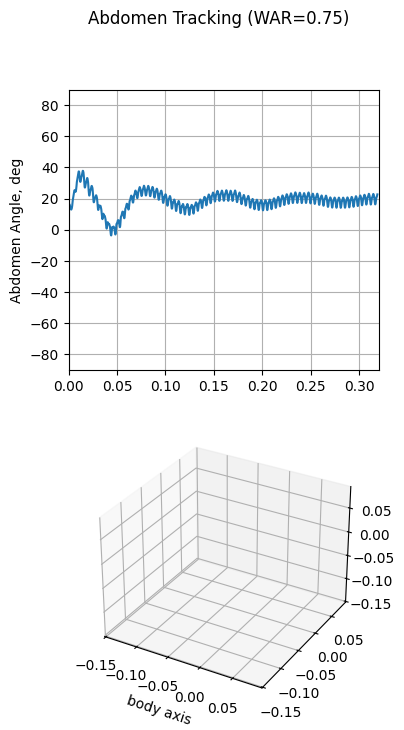

In [ ]:
#media.show_videos(videos)
import matplotlib.animation as pltAnim
%matplotlib inline

fig = plt.figure(figsize=plt.figaspect(2.))
fig.suptitle("Abdomen Tracking (WAR=0.75)")
n      = results["cloop"]["Trial_000"]["abdomen_vecang"].shape[0]
t      = results["cloop"]["Trial_025"]["timestep"]*np.arange(0,n)
x      = results["cloop"]["Trial_025"]["abdomen_vecang"]

# First subplot, abdomen angle
ax = fig.add_subplot(2,1,1)
oneD   = ax.plot(t[0],x[0,3])
ax.set(xlim=[0,np.max(t)], ylim=[-90,90])
ax.grid(True)
ax.set_ylabel("Abdomen Angle, deg")

# Second subplot, 3D reconstruction
ax = fig.add_subplot(2,1,2,projection='3d')
threeD = ax.plot([0,x[0,0]],[0,x[0,1]],[0,x[0,2]])
absBound = [np.nanmin(x[:,:3]),np.nanmax(x[:,:3])]
ax.set(xlim=absBound, ylim=absBound, zlim=absBound)
ax.set_xlabel("body axis")

def update(frame):
    # for each frame...
    oneD[0].set_xdata(t[:frame])
    oneD[0].set_ydata(x[:frame,3])
    threeD[0].set_data_3d([0,x[frame,0]],[0,x[frame,1]],[0,x[frame,2]])
    return (oneD[0],threeD[0])

ani = pltAnim.FuncAnimation(fig=fig, func=update, frames=n, interval=30)
ani.save("/home/exj5139/Downloads/abdomenAni.mp4")
plt.show()

In [7]:
time = np.arange(n_steps)*_FLY_CONTROL_TIMESTEP
force = results["force"]
torque = results["torque"]
accel  = results["acceleration"]/981.
plt.figure()
f_avg = np.nanmean(force[:,2])
a_avg = np.nanmean(accel[:,2])
plt.plot(time,force[:,2], linewidth=0.75)
plt.plot(time,accel[:,2], linewidth=0.75)
# for i in range(3): plt.axhline(f_avg[i])
plt.xlim((0.1,0.15))
# plt.legend(("x","y","z"))
plt.axhline(f_avg,color="tab:blue")
plt.axhline(a_avg,color="tab:orange")
plt.legend((f"force-based: mean={round(f_avg,3)}",f"accel-based: mean={round(a_avg,3)}"))
plt.title("Normalized Vertical Force (v=[0,0,20]cm/s)")
plt.xlabel("time, s")
print(f_avg,a_avg)

plt.figure()
m_avg = np.nanmean(torque[:1],0)
plt.plot(time[1:],torque[1:])
for i in range(3): plt.axhline(m_avg[i])
# plt.xlim((0,0.05))
# plt.legend(("x","y","z"))
print(m_avg)

KeyError: 'force'

In [ ]:
np.set_printoptions(threshold=np.inf)
force